In [215]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import math
# Необходимые библеотеки

In [216]:
# Загружаем, целевая перемая selling_price пытаемся предсказать цену автомобиля
data1 = pd.read_csv(r'C:\Users\Ignite_IgniS\PycharmProjects\tpu-8e22-ML-course-Mishenkov\Mischenkov_N\data\raw\car_data.csv')
data2 = pd.read_csv(r'C:\Users\Ignite_IgniS\PycharmProjects\tpu-8e22-ML-course-Mishenkov\Mischenkov_N\data\raw\CAR_DETAILS_FROM_CAR_DEKHO.csv')
data3 = pd.read_csv(r'C:\Users\Ignite_IgniS\PycharmProjects\tpu-8e22-ML-course-Mishenkov\Mischenkov_N\data\raw\Car_details_v3.csv')

In [217]:
# Смотрим на таблицы в общем виде
data1.head()
# data['Car_Name'].unique()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [218]:
data2
# data1['owner'].unique()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
3,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
4,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
...,...,...,...,...,...,...,...,...
4031,Maruti Ritz VDi,2012,225000,90000,Diesel,Individual,Manual,Second Owner
4032,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4033,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4034,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner


In [219]:
data3

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7554,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
7555,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
7556,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
7557,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0


In [220]:
# удалим дубликаты
print(data1.duplicated().sum())
print(data2.duplicated().sum())
print(data3.duplicated().sum())
data1.drop_duplicates(inplace=True, ignore_index=True)
data2.drop_duplicates(inplace=True, ignore_index=True)
data3.drop_duplicates(inplace=True, ignore_index=True)
print('==========================')
print(data1.duplicated().sum())
print(data2.duplicated().sum())
print(data3.duplicated().sum())

2
667
1062
0
0
0


In [221]:
amount1 = len(data1)
amount2 = len(data2)
amount3 = len(data3)
print('Amount of string:', amount1)
print('Amount of string:', amount2)
print('Amount of string:', amount3)
print('------------')
print (data1.describe())
print (data2.describe())
print (data3.describe())

Amount of string: 278
Amount of string: 3369
Amount of string: 6497
------------
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   278.000000     278.000000     278.000000     278.000000  278.000000
mean   2013.636691       4.541978       7.375755   36857.895683    0.043165
std       2.899213       4.783034       7.186268   39828.183345    0.251221
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.785000       1.050000   15000.000000    0.000000
50%    2014.000000       3.495000       6.250000   31515.500000    0.000000
75%    2016.000000       6.075000       9.900000   49000.000000    0.000000
max    2018.000000      33.000000      36.230000  500000.000000    3.000000
              year  selling_price      km_driven
count  3369.000000   3.369000e+03    3369.000000
mean   2012.963787   4.715830e+05   68913.409023
std       4.269971   4.939631e+05   47533.176498
min    1992.000000   2.000000e+04      

In [222]:
# Выведем статистику датасетов
data3.dropna()
tab1 = data1.isnull().sum(); tab2 = data2.isnull().sum(); tab3 = data3.isnull().sum()
tab = pd.concat([tab1, tab2, tab3], axis=1)
print(tab)

                 0    1      2
Car_Name       0.0  NaN    NaN
Year           0.0  NaN    NaN
Selling_Price  0.0  NaN    NaN
Present_Price  0.0  NaN    NaN
Kms_Driven     0.0  NaN    NaN
Fuel_Type      0.0  NaN    NaN
Seller_Type    0.0  NaN    NaN
Transmission   0.0  NaN    NaN
Owner          0.0  NaN    NaN
name           NaN  0.0    0.0
year           NaN  0.0    0.0
selling_price  NaN  0.0    0.0
km_driven      NaN  0.0    0.0
fuel           NaN  0.0    0.0
seller_type    NaN  0.0    0.0
transmission   NaN  0.0    0.0
owner          NaN  0.0    0.0
mileage        NaN  NaN  191.0
engine         NaN  NaN  191.0
max_power      NaN  NaN  188.0
torque         NaN  NaN  192.0
seats          NaN  NaN  191.0


# Первая таблица важна?
Поскольку первая таблица не соответствует структуре остальных данных и составляет менее 3% от общего объёма, целесообразно исключить её из общего набора данных.

In [223]:
print(278/(278+3369+6497) * 100,'%')

2.7405362776025237 %


In [224]:
# пробублируем таблицы 2 и 3
data2

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
3,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
4,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
...,...,...,...,...,...,...,...,...
3364,Maruti Ritz VDi,2012,225000,90000,Diesel,Individual,Manual,Second Owner
3365,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
3366,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
3367,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner


In [225]:
data3
data3['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

# Как заполнить пропуски эффективно?
Обусловим что data2 - это таблица 1 и соответственно data3 - это таблица 2. Найдем дупликаты по 'name' в дух

In [226]:
specific_row = data2[data2['name'] == 'Tata Indigo Grand Petrol']
specific_row

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
5,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
9,Tata Indigo Grand Petrol,2014,250000,100000,Petrol,Individual,Manual,First Owner


In [227]:
specific_row = data3[data3['name'] == 'Tata Indigo Grand Petrol']
specific_row

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
5495,Tata Indigo Grand Petrol,2008,135000,40000,Petrol,Individual,Manual,Fourth & Above Owner,12.85 kmpl,1396 CC,99.6 bhp,124Nm@ 3500rpm,5.0


# Как объединяем datasets? 
## Задачи
Основная:
1) Объединить датасеты
Второстепенные:
1) Колонка name мало информативна, разделим её на brand (e.g. - Maruti) и model (e.g. - Swift Dzire VDI).
2) Переведем 'owner' в числовой вид.
3) torque - крутящий момент можно исключить или разделить на два столбца Nm - крутящий момент и rpm - обороты двигателя
4) max_power, engine, mileage - переведем в числовой вид


In [228]:
# Создадим копии для удобства
df2 = data3.copy()
df1 = data2.copy()

In [229]:
pd.set_option('future.no_silent_downcasting', True)
duplicates = pd.merge(df1[['name']], df2[['name']], on='name')
duplicates_from_df1 = df1[df1['name'].isin(duplicates['name'])]
combined_df = pd.concat([duplicates_from_df1, df2], axis=0)
cols_to_fill = ['mileage', 'engine', 'max_power', 'torque', 'seats']
for col in cols_to_fill:
    combined_df[col] = combined_df.groupby('name')[col].transform(lambda group: group.bfill().ffill())

# combined_df
specific_row = combined_df[combined_df['name'] == 'Hyundai i20 Magna 1.4 CRDi']
specific_row


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
3366,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,21.9 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
789,Hyundai i20 Magna 1.4 CRDi,2010,270000,100000,Diesel,Individual,Manual,Fourth & Above Owner,21.9 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
3066,Hyundai i20 Magna 1.4 CRDi,2016,550000,90000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
6493,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0


In [230]:
print(combined_df.isnull().sum())
combined_df = combined_df.dropna()
print(combined_df.isnull().sum())
# так как 204 строки это всего лишь 204/9304 = 0,0219 ~ 2%, следовательно, можем их удалить

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          204
engine           204
max_power        204
torque           206
seats            204
dtype: int64
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64


In [231]:
combined_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,16.1 kmpl,796 CC,37 bhp,59Nm@ 2500rpm,4.0
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1061 CC,67 bhp,84Nm@ 3500rpm,5.0
2,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,22.7 kmpl,799 CC,53.64 bhp,72Nm@ 4386rpm,5.0
3,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,25.8 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0
4,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner,19.7 kmpl,796 CC,46.3 bhp,62Nm@ 3000rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm,5.0
6493,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54 kmpl,1396 CC,88.73 bhp,219.7Nm@ 1500-2750rpm,5.0
6494,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
6495,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0


### Как объединили?
Мы сравниваем две таблицы и находим все совпадающие названия (столбец 'name'). Это позволяет нам увидеть, какие автомобили есть и в первой, и во второй таблице. Затем мы берем только те строки из первой таблицы, которые имеют совпадающие названия с той таблицей, которую мы проверяли на дубликаты. Это нужно, чтобы работать только с теми данными, которые нас интересуют(так как остальные строки мы заполнить не сможем). Мы соединяем отфильтрованные данные из первой таблицы с данными второй таблицы. Таким образом, у нас получается одна большая таблица, которая содержит дубликаты с дополнительной информацией. Появились соответствующие пропуски в столбцах (['mileage', 'engine', 'max_power', 'torque', 'seats']), но мы учли их заполнение заранее. Теперь мы заполняем эти пропуски, используя информацию из строк с тем же названием автомобиля. Если для одной модели существуют данные о расходе или мощности в других строках, мы копируем эти данные, чтобы у нас была полная информация. Для проверки мы можем выбрать конкретный автомобиль, например, "Hyundai i20 Magna 1.4 CRDi", и получить все данные о нем из большой объединенной таблицы. Это позволяет нам быстро видеть всю информацию только по интересующей нас модели. Теперь мы имеем датасет с полными сведениями на 9100 строк, это большой объем данных для анализа рынка.

In [232]:
print(combined_df.isnull().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64


In [233]:
# Продолжаем преобразовывать
combined_df[['brand', 'model']] = combined_df['name'].str.extract(r'(\w+)\s(.+)', expand=True)
combined_df.drop('name', axis=1, inplace=True)

# Преобразование 'owner' в числовой вид
owner_mapping = {'Test Drive Car': 0, 'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3, 'Fourth & Above Owner': 4}
combined_df['owner'] = combined_df['owner'].map(owner_mapping)

# Разделение столбца 'torque'
# Сначала извлекаем значения без преобразования в int
regex = r'(\d+\.?\d*)\s?(?:Nm|nm|kgm)?.*?(\d+\.?\d*)(?:-\d+)?\s?(rpm|RPM)?'

# Используем `.str.extract()` для извлечения данных
torque_df = combined_df['torque'].str.extract(regex, expand=True)

# Преобразуем извлеченные числовые данные в float
combined_df['Nm'] = pd.to_numeric(torque_df[0], errors='coerce')  # Значение момента, Nm
combined_df['rpm'] = pd.to_numeric(torque_df[1], errors='coerce')  # Среднее значение rpm

# Преобразование столбцов в числовой вид
for col in ['max_power', 'engine', 'mileage']:
    combined_df[col] = combined_df[col].astype(str).str.extract('(\d+\.?\d*)').astype(float)

In [234]:
combined_df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand,model,Nm,rpm
0,2007,60000,70000,Petrol,Individual,Manual,1,16.10,796.0,37.00,59Nm@ 2500rpm,4.0,Maruti,800 AC,59.0,2500.0
1,2007,135000,50000,Petrol,Individual,Manual,1,18.90,1061.0,67.00,84Nm@ 3500rpm,5.0,Maruti,Wagon R LXI Minor,84.0,3500.0
2,2017,250000,46000,Petrol,Individual,Manual,1,22.70,799.0,53.64,72Nm@ 4386rpm,5.0,Datsun,RediGO T Option,72.0,4386.0
3,2014,450000,141000,Diesel,Individual,Manual,2,25.80,1498.0,98.60,200Nm@ 1750rpm,5.0,Honda,Amaze VX i-DTEC,200.0,1750.0
4,2007,140000,125000,Petrol,Individual,Manual,1,19.70,796.0,46.30,62Nm@ 3000rpm,5.0,Maruti,Alto LX BSIII,62.0,3000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,2013,260000,50000,Petrol,Individual,Manual,2,18.90,998.0,67.10,90Nm@ 3500rpm,5.0,Maruti,Wagon R VXI BS IV with ABS,90.0,3500.0
6493,2014,475000,80000,Diesel,Individual,Manual,2,22.54,1396.0,88.73,219.7Nm@ 1500-2750rpm,5.0,Hyundai,i20 Magna 1.4 CRDi,219.7,1500.0
6494,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,113.7Nm@ 4000rpm,5.0,Hyundai,i20 Magna,113.7,4000.0
6495,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,"24@ 1,900-2,750(kgm@ rpm)",5.0,Hyundai,Verna CRDi SX,24.0,1.0


In [235]:
print(combined_df.isnull().sum())

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
brand            0
model            0
Nm               0
rpm              0
dtype: int64


In [236]:
combined_df['price_category'] = np.where(combined_df['selling_price'] > 1_000_000, 'Premium', 'Casual')
# Создадим новый признак, страна - производитель
country_brand_mapping = {
    'India': 'Maruti, Tata, Mahindra, Force, Ambassador, Ashok',
    'Japan': 'Datsun, Honda, Toyota, Nissan, Mitsubishi, Lexus, Isuzu',
    'South Korea': 'Hyundai, Kia, Daewoo',
    'USA': 'Chevrolet, Ford, Jeep',
    'Europe': 'Jaguar, Benz, Audi, BMW, Volkswagen, Opel, Skoda, Renault',
    'Italy': 'Fiat',
    'Sweden': 'Volvo',
    'UK': 'Land, MG'
}
def get_country_by_brand(brand):
    for country, brands in country_brand_mapping.items():
        # Разделяем строку с брендами в список (по ', ')
        if brand in brands.split(', '):
            return country  # Возвращаем ключ, если бренд найден
    return None
combined_df['country'] = combined_df['brand'].apply(get_country_by_brand)
# Удаление исходного столбца 'torque'
combined_df.drop('torque', axis=1, inplace=True)
combined_df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand,model,Nm,rpm,price_category,country
0,2007,60000,70000,Petrol,Individual,Manual,1,16.10,796.0,37.00,4.0,Maruti,800 AC,59.0,2500.0,Casual,India
1,2007,135000,50000,Petrol,Individual,Manual,1,18.90,1061.0,67.00,5.0,Maruti,Wagon R LXI Minor,84.0,3500.0,Casual,India
2,2017,250000,46000,Petrol,Individual,Manual,1,22.70,799.0,53.64,5.0,Datsun,RediGO T Option,72.0,4386.0,Casual,Japan
3,2014,450000,141000,Diesel,Individual,Manual,2,25.80,1498.0,98.60,5.0,Honda,Amaze VX i-DTEC,200.0,1750.0,Casual,Japan
4,2007,140000,125000,Petrol,Individual,Manual,1,19.70,796.0,46.30,5.0,Maruti,Alto LX BSIII,62.0,3000.0,Casual,India
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,2013,260000,50000,Petrol,Individual,Manual,2,18.90,998.0,67.10,5.0,Maruti,Wagon R VXI BS IV with ABS,90.0,3500.0,Casual,India
6493,2014,475000,80000,Diesel,Individual,Manual,2,22.54,1396.0,88.73,5.0,Hyundai,i20 Magna 1.4 CRDi,219.7,1500.0,Casual,South Korea
6494,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,5.0,Hyundai,i20 Magna,113.7,4000.0,Casual,South Korea
6495,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,5.0,Hyundai,Verna CRDi SX,24.0,1.0,Casual,South Korea


In [237]:
combined_df['fuel'].unique()
combined_df['transmission'].unique()
combined_df['seller_type'].unique()
combined_df['owner'].unique()

array([1, 2, 4, 3, 0])

In [238]:
# Добавим новый признак - возраст автомобиля
current_year = 2025  # Текущий год
combined_df['years_old'] = current_year - combined_df['year']
# combined_df.drop('year', axis=1, inplace=True)
combined_df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand,model,Nm,rpm,price_category,country,years_old
0,2007,60000,70000,Petrol,Individual,Manual,1,16.10,796.0,37.00,4.0,Maruti,800 AC,59.0,2500.0,Casual,India,18
1,2007,135000,50000,Petrol,Individual,Manual,1,18.90,1061.0,67.00,5.0,Maruti,Wagon R LXI Minor,84.0,3500.0,Casual,India,18
2,2017,250000,46000,Petrol,Individual,Manual,1,22.70,799.0,53.64,5.0,Datsun,RediGO T Option,72.0,4386.0,Casual,Japan,8
3,2014,450000,141000,Diesel,Individual,Manual,2,25.80,1498.0,98.60,5.0,Honda,Amaze VX i-DTEC,200.0,1750.0,Casual,Japan,11
4,2007,140000,125000,Petrol,Individual,Manual,1,19.70,796.0,46.30,5.0,Maruti,Alto LX BSIII,62.0,3000.0,Casual,India,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,2013,260000,50000,Petrol,Individual,Manual,2,18.90,998.0,67.10,5.0,Maruti,Wagon R VXI BS IV with ABS,90.0,3500.0,Casual,India,12
6493,2014,475000,80000,Diesel,Individual,Manual,2,22.54,1396.0,88.73,5.0,Hyundai,i20 Magna 1.4 CRDi,219.7,1500.0,Casual,South Korea,11
6494,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,5.0,Hyundai,i20 Magna,113.7,4000.0,Casual,South Korea,12
6495,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,5.0,Hyundai,Verna CRDi SX,24.0,1.0,Casual,South Korea,18


In [239]:
# Пробег в зависимости от возраста - показывает насколько часто использовался автомобиль
combined_df['km_per_year'] = combined_df['km_driven'] / ( combined_df['years_old'] + 0.000001)
# Чем больше владельцев, тем вероятнее, что автомобиль был менее тщательно поддержан.
combined_df['km_per_owner'] = combined_df['km_driven'] / ( combined_df['owner'] + 0.000001) # тут есть нули
# Удельный расход топлива на единицу объема двигателя. 
# Насколько эффективно двигатель использует топливо относительно своего объема. Чем ниже результат, тем более эффективно двигатель расходует топливо.
combined_df['fuel_consumption'] = combined_df['engine'] / ( combined_df['mileage'] + 0.000001)
combined_df

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,brand,model,Nm,rpm,price_category,country,years_old,km_per_year,km_per_owner,fuel_consumption
0,2007,60000,70000,Petrol,Individual,Manual,1,16.10,796.0,37.00,...,Maruti,800 AC,59.0,2500.0,Casual,India,18,3888.888673,69999.930000,49.440991
1,2007,135000,50000,Petrol,Individual,Manual,1,18.90,1061.0,67.00,...,Maruti,Wagon R LXI Minor,84.0,3500.0,Casual,India,18,2777.777623,49999.950000,56.137563
2,2017,250000,46000,Petrol,Individual,Manual,1,22.70,799.0,53.64,...,Datsun,RediGO T Option,72.0,4386.0,Casual,Japan,8,5749.999281,45999.954000,35.198236
3,2014,450000,141000,Diesel,Individual,Manual,2,25.80,1498.0,98.60,...,Honda,Amaze VX i-DTEC,200.0,1750.0,Casual,Japan,11,12818.180653,70499.964750,58.062013
4,2007,140000,125000,Petrol,Individual,Manual,1,19.70,796.0,46.30,...,Maruti,Alto LX BSIII,62.0,3000.0,Casual,India,18,6944.444059,124999.875000,40.406089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,2013,260000,50000,Petrol,Individual,Manual,2,18.90,998.0,67.10,...,Maruti,Wagon R VXI BS IV with ABS,90.0,3500.0,Casual,India,12,4166.666319,24999.987500,52.804230
6493,2014,475000,80000,Diesel,Individual,Manual,2,22.54,1396.0,88.73,...,Hyundai,i20 Magna 1.4 CRDi,219.7,1500.0,Casual,South Korea,11,7272.726612,39999.980000,61.934336
6494,2013,320000,110000,Petrol,Individual,Manual,1,18.50,1197.0,82.85,...,Hyundai,i20 Magna,113.7,4000.0,Casual,South Korea,12,9166.665903,109999.890000,64.702699
6495,2007,135000,119000,Diesel,Individual,Manual,4,16.80,1493.0,110.00,...,Hyundai,Verna CRDi SX,24.0,1.0,Casual,South Korea,18,6611.110744,29749.992563,88.869042


In [240]:
combined_df['price_category'].describe()

count       9100
unique         2
top       Casual
freq        8496
Name: price_category, dtype: object

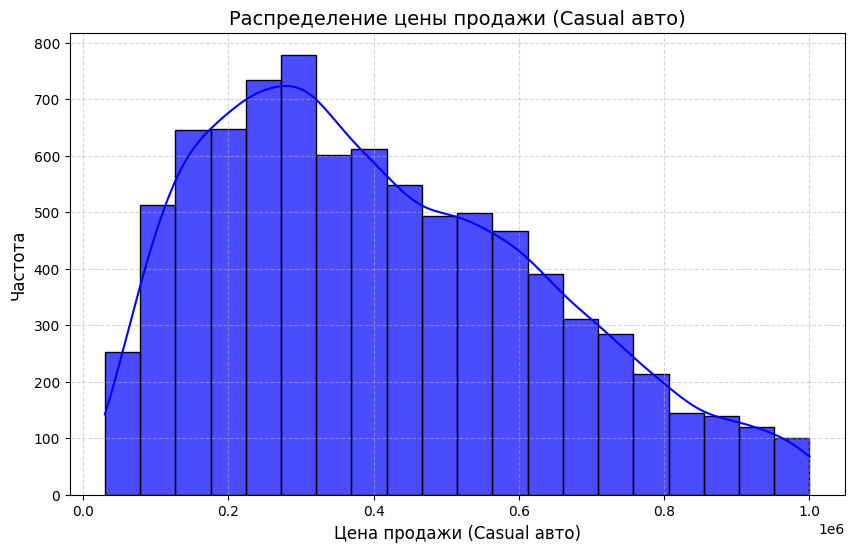

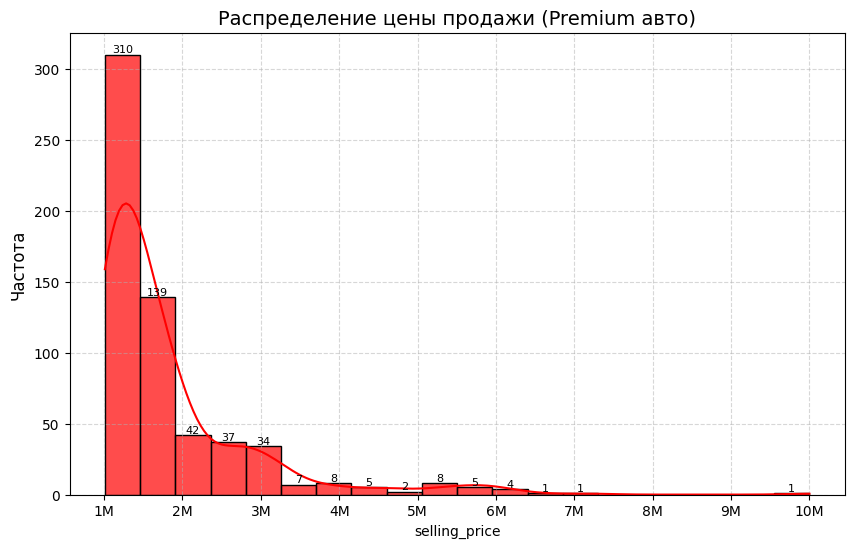

In [241]:
import matplotlib.ticker as ticker
# Создание графика для Casual автомобилей
plt.figure(figsize=(10, 6))
sns.histplot(combined_df[combined_df['price_category'] == 'Casual']['selling_price'], 
             bins=20, kde=True, color='blue', alpha=0.7)
plt.xlabel('Цена продажи (Casual авто)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение цены продажи (Casual авто)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Создание графика для Premium автомобилей
plt.figure(figsize=(10, 6))
ax_premium = sns.histplot(combined_df[combined_df['price_category'] == 'Premium']['selling_price'], 
                          bins=20, kde=True, color='red', alpha=0.7)

# Масштабирование оси X в миллионах
ax_premium.xaxis.set_major_locator(ticker.MultipleLocator(1e6))
ax_premium.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:.0f}M'.format(x / 1e6)))

# Добавление количества автомобилей над каждым столбцом
for p in ax_premium.patches:
    height = int(p.get_height())  # Получение высоты столбца (частота)
    if height > 0:  # Исключаем столбцы с нулевой высотой
        ax_premium.annotate(f'{height}', 
                            (p.get_x() + p.get_width() / 2, height),  # Координаты текста
                            ha='center', va='bottom', fontsize=8)

# Масштабирование оси X в миллионах
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1e6))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:.0f}M'.format(x/1e6)))

plt.ylabel('Частота', fontsize=12)
plt.title('Распределение цены продажи (Premium авто)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

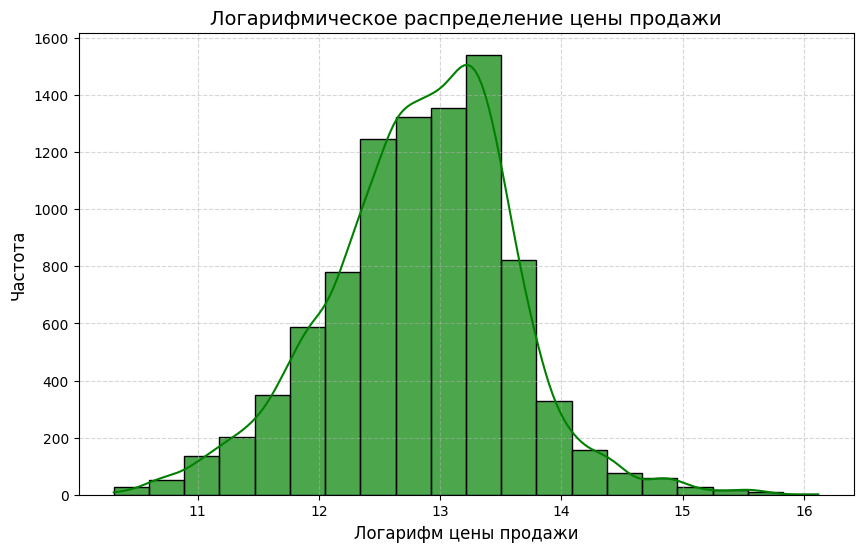

In [242]:
# Преобразование данных в логарифмическую шкалу
log_selling_price = np.log(combined_df['selling_price'])

# Построение гистограммы
plt.figure(figsize=(10, 6))
sns.histplot(log_selling_price, bins=20, kde=True, color='green', alpha=0.7)

# Настройка подписей и заголовка
plt.xlabel('Логарифм цены продажи', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Логарифмическое распределение цены продажи', fontsize=14)

# Включение сетки
plt.grid(True, linestyle='--', alpha=0.5)

# Отображение графика
plt.show()


#### Вывод:


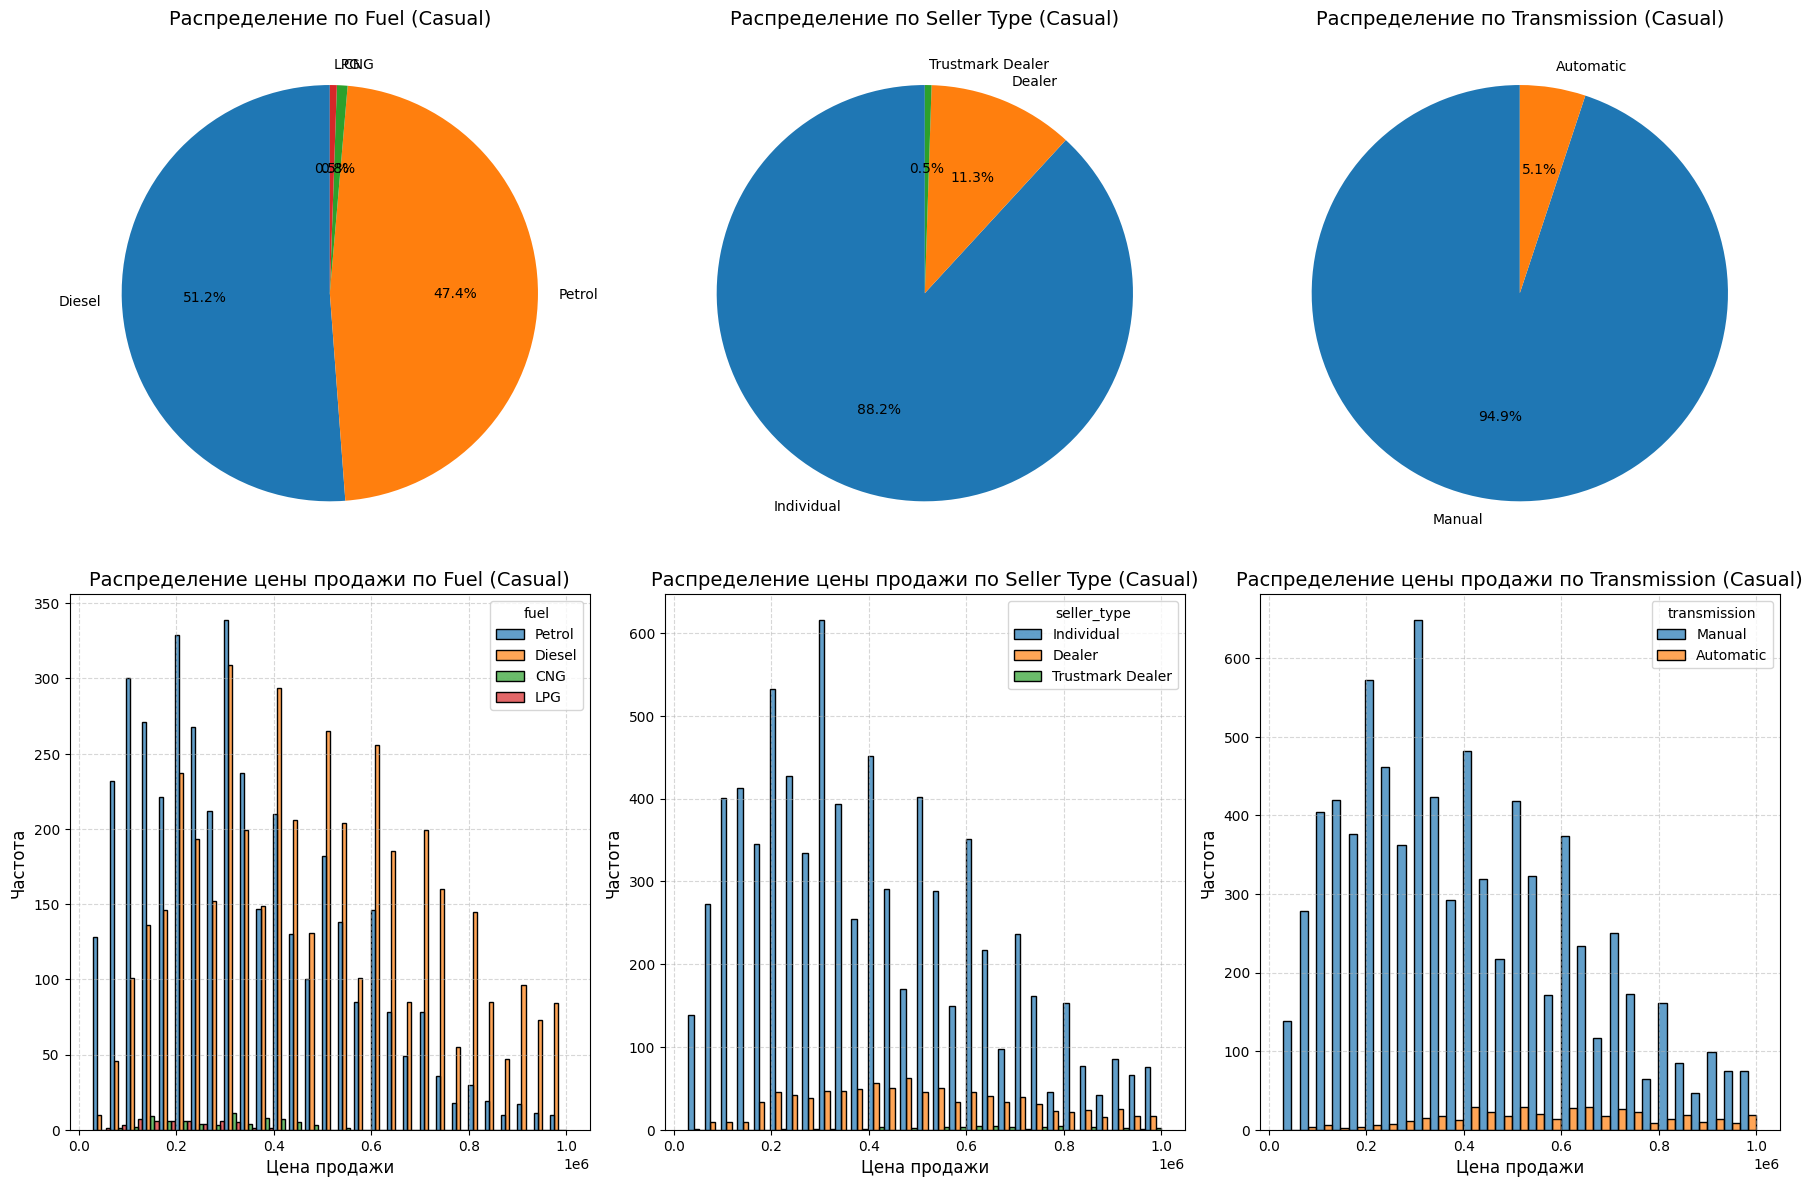

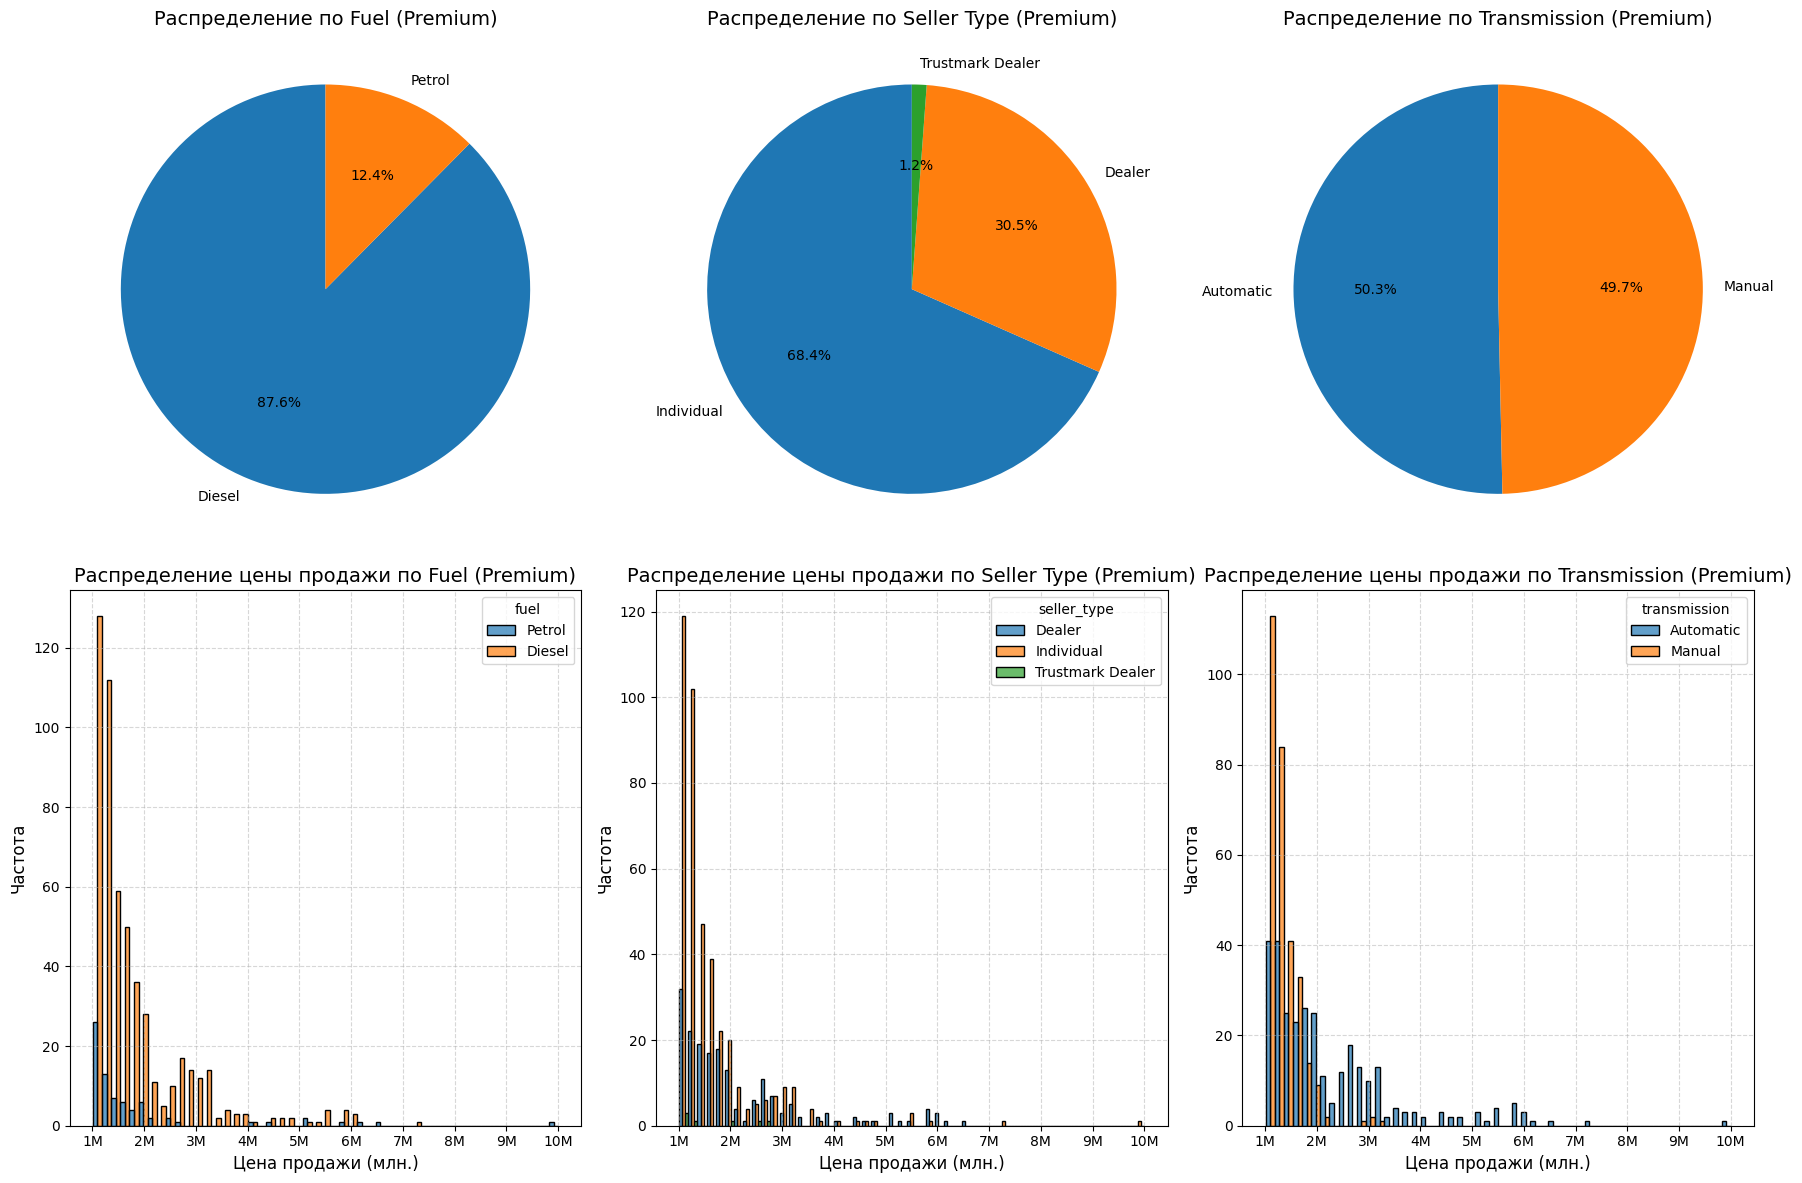

In [243]:
# Список столбцов для анализа
columns = ['fuel', 'seller_type', 'transmission']

# Создание фигуры с субплотами для Casual автомобилей
fig_casual, axs_casual = plt.subplots(2, 3, figsize=(18, 12))

for i, column in enumerate(columns):
    # Подсчет значений для каждой категории в сегменте Casual
    value_counts_casual = combined_df[combined_df['price_category'] == 'Casual'][column].value_counts()

    # Создание круговой диаграммы
    axs_casual[0, i].pie(value_counts_casual.values, 
                         labels=value_counts_casual.index,
                         autopct='%1.1f%%',  # Показывать проценты
                         startangle=90)      # Начальный угол

    axs_casual[0, i].set_title(f'Распределение по {column.replace("_", " ").title()} (Casual)', fontsize=14)

# Цикл для построения гистограмм цены для Casual автомобилей
for i, column in enumerate(columns):
    sns.histplot(data=combined_df[combined_df['price_category'] == 'Casual'], 
                 x='selling_price', hue=column, multiple="dodge", kde=False, alpha=0.7, edgecolor='black', linewidth=1, ax=axs_casual[1, i])

    axs_casual[1, i].set_xlabel('Цена продажи', fontsize=12)
    axs_casual[1, i].set_ylabel('Частота', fontsize=12)
    axs_casual[1, i].set_title(f'Распределение цены продажи по {column.replace("_", " ").title()} (Casual)', fontsize=14)
    axs_casual[1, i].grid(True, linestyle='--', alpha=0.5)

# Отображение графиков для Casual автомобилей
plt.tight_layout()
plt.show()

# Создание фигуры с субплотами для Premium автомобилей
fig_premium, axs_premium = plt.subplots(2, 3, figsize=(18, 12))

for i, column in enumerate(columns):
    # Подсчет значений для каждой категории в сегменте Premium
    value_counts_premium = combined_df[combined_df['price_category'] == 'Premium'][column].value_counts()

    # Создание круговой диаграммы
    axs_premium[0, i].pie(value_counts_premium.values, 
                          labels=value_counts_premium.index,
                          autopct='%1.1f%%',  # Показывать проценты
                          startangle=90)      # Начальный угол

    axs_premium[0, i].set_title(f'Распределение по {column.replace("_", " ").title()} (Premium)', fontsize=14)

# Цикл для построения гистограмм цены для Premium автомобилей
for i, column in enumerate(columns):
    sns.histplot(data=combined_df[combined_df['price_category'] == 'Premium'], 
                 x='selling_price', hue=column, multiple="dodge", kde=False, alpha=0.7, edgecolor='black', linewidth=1, ax=axs_premium[1, i])

    axs_premium[1, i].set_xlabel('Цена продажи (млн.)', fontsize=12)
    axs_premium[1, i].set_ylabel('Частота', fontsize=12)
    axs_premium[1, i].set_title(f'Распределение цены продажи по {column.replace("_", " ").title()} (Premium)', fontsize=14)
    axs_premium[1, i].grid(True, linestyle='--', alpha=0.5)
    
    # Масштабирование оси X в миллионах
    axs_premium[1, i].xaxis.set_major_locator(ticker.MultipleLocator(1e6))
    axs_premium[1, i].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:.0f}M'.format(x / 1e6)))

# Отображение графиков для Premium автомобилей
plt.tight_layout()
plt.show()


#### Общий вывод по всем графикам: 


In [244]:
# Исследуем влияния признаков связанных с двигателем
print(combined_df['max_power'].describe())
print(combined_df['engine'].describe())

count    9100.000000
mean       87.092556
std        31.599572
min         0.000000
25%        67.100000
50%        81.830000
75%        99.000000
max       400.000000
Name: max_power, dtype: float64
count    9100.000000
mean     1416.221978
std       489.525539
min       624.000000
25%      1196.000000
50%      1248.000000
75%      1498.000000
max      3604.000000
Name: engine, dtype: float64


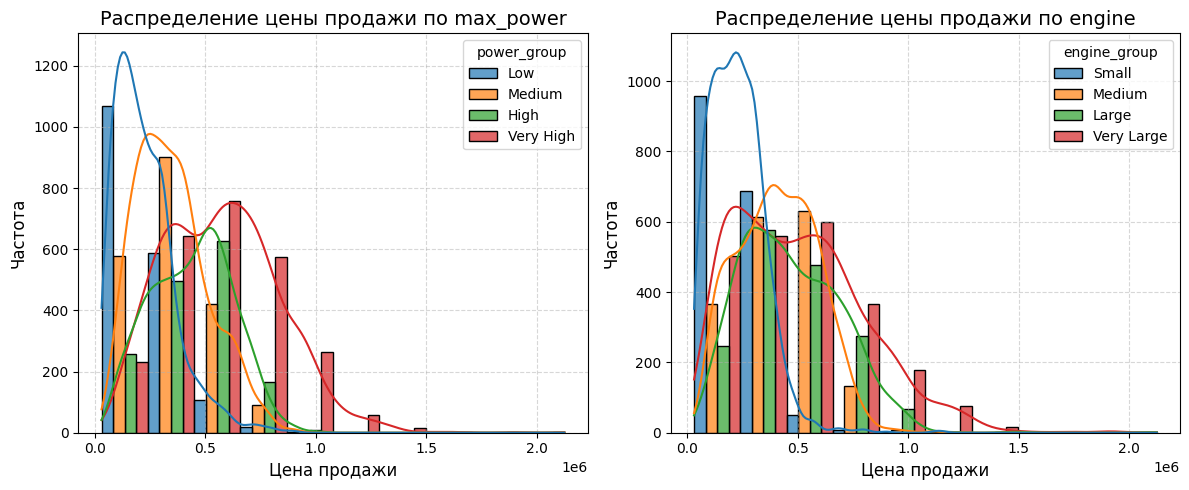

In [245]:
# Создание групп по мощности и объёму двигателя
# Группировка с учётом описательной статистики
combined_df_copy = combined_df.copy()
combined_df_copy['power_group'] = pd.cut(combined_df_copy['max_power'], 
                                    bins=[35, 67, 74, 86, 120], 
                                    labels=['Low', 'Medium', 'High', 'Very High'])

combined_df_copy['engine_group'] = pd.cut(combined_df_copy['engine'], 
                                     bins=[793, 999, 1198, 1368, 1600], 
                                     labels=['Small', 'Medium', 'Large', 'Very Large'])

# Создание фигуры с субплотами
plt.figure(figsize=(12, 5))

# Гистограмма: цена продажи vs группа мощности
plt.subplot(1, 2, 1)
sns.histplot(data=combined_df_copy.dropna(subset=['selling_price', 'power_group']), 
             x='selling_price', 
             hue='power_group', 
             multiple="dodge", 
             bins=10,
             kde=True,
             alpha=0.7, 
             edgecolor='black', 
             linewidth=1)
plt.xlabel('Цена продажи', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение цены продажи по max_power', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Гистограмма: цена продажи vs группа объёма двигателя
plt.subplot(1, 2, 2)
sns.histplot(data=combined_df_copy.dropna(subset=['selling_price', 'engine_group']), 
             x='selling_price', 
             hue='engine_group', 
             multiple="dodge", 
             bins=10, 
             alpha=0.7,
             kde=True,
             edgecolor='black', 
             linewidth=1)
plt.xlabel('Цена продажи', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение цены продажи по engine', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Отображение графиков
plt.tight_layout()
plt.show()


## Выводы:
### График "Распределение цены продажи по max_power"
Распределение цен продажи автомобилей по максимальной мощности двигателя показывает, что более мощные двигатели соответствуют более высоким ценам продажи. Однако, важно заметить, что максимумы KDE-линий для каждой группы смещаются влево, что указывает на асимметрию распределения. Это может свидетельствовать о том, что распределение цен продажи автомобилей по максимальной мощности двигателя имеет долгий правый "хвост", т.е. существует определенное количество автомобилей с достаточно высокими ценами.
### График "Распределение цены продажи по engine"
Распределение цен продажи автомобилей по объёму двигателя также показывает неравномерность, с более высокими ценами для категорий "Large" и "Very Large". Максимумы KDE-линий для каждой группы также смещаются влево, что указывает на асимметрию распределения. Это может свидетельствовать о том, что распределение цен продажи автомобилей по объёму двигателя также имеет долгий правый "хвост". 

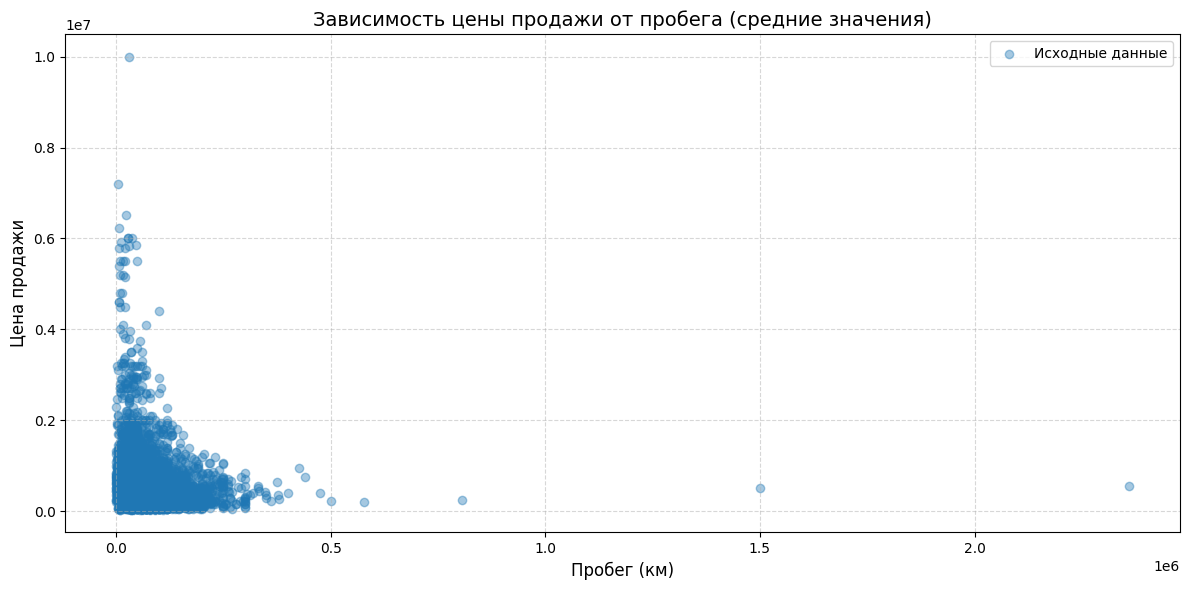

In [246]:
bin_size = 10000  # Размер одного интервала
combined_df_copy = combined_df.copy()
combined_df_copy['km_bins'] = pd.cut(combined_df_copy['km_driven'], bins=range(0, combined_df_copy['km_driven'].max() + bin_size, bin_size))

# Сгруппировать по интервалам (km_bins) и рассчитать среднее значение selling_price
grouped_df = combined_df_copy.groupby('km_bins', observed=False).agg(
    km_mean=('km_driven', 'mean'),  # Средний пробег в интервале (для X)
    selling_price_mean=('selling_price', 'mean')  # Средняя цена продажи (для Y)
).reset_index()

# Построение графика
plt.figure(figsize=(12, 6))

# Линия, соединяющая точки средней цены
# plt.plot(grouped_df['km_mean'], grouped_df['selling_price_mean'], marker='o', color='red', label='Средняя цена продажи')

# График рассеяния для исходных данных
plt.scatter(combined_df_copy['km_driven'], combined_df_copy['selling_price'], alpha=0.4, label='Исходные данные')

# Настройка подписей
plt.xlabel('Пробег (км)', fontsize=12)
plt.ylabel('Цена продажи', fontsize=12)
plt.title('Зависимость цены продажи от пробега (средние значения)', fontsize=14)
plt.legend()

# Добавление сетки
plt.grid(True, linestyle='--', alpha=0.5)

# Отображение графика
plt.tight_layout()
plt.show()

### Очевидные выбросы
Ниже представлен график, на котором видно (выделено красным квадратом), что эти данные значительно отличаются от общей выборки датасета. В связи с этим, мы удалим их, так как они являются выбросами.

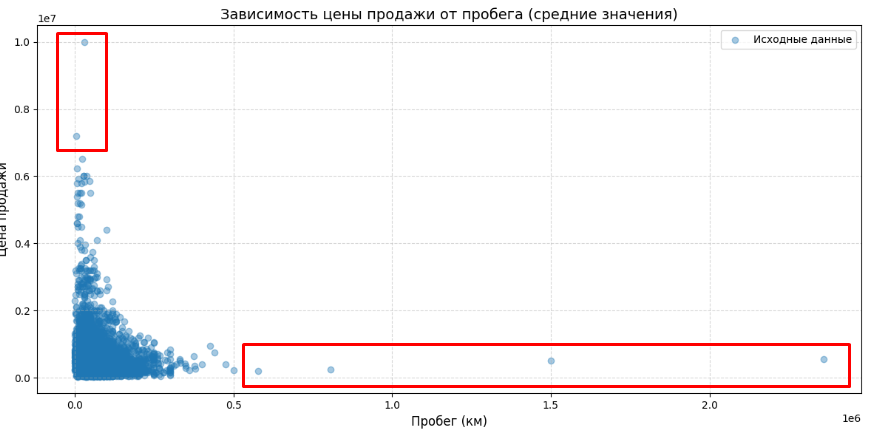

In [247]:
# Вывод двух машин с наивысшей ценой
combined_df.nlargest(2, 'selling_price')

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,brand,model,Nm,rpm,price_category,country,years_old,km_per_year,km_per_owner,fuel_consumption
159,2017,10000000,30000,Petrol,Individual,Automatic,1,42.00,1969.0,400.0,...,Volvo,XC90 T8 Excellence BSIV,640.0,1740.0,Premium,Sweden,8,3749.999531,29999.970,46.880951
2500,2020,7200000,5000,Diesel,Individual,Automatic,1,13.38,2993.0,265.0,...,BMW,X7 xDrive 30d DPE,620.0,1500.0,Premium,Europe,5,999.999800,4999.995,223.692061


In [248]:
# Вывод 4 машин с наивысшим пробегом
combined_df.nlargest(4, 'km_driven')

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,brand,model,Nm,rpm,price_category,country,years_old,km_per_year,km_per_owner,fuel_consumption
2945,2007,550000,2360457,Petrol,Individual,Manual,2,18.6,1197.0,81.83,...,Hyundai,i20 Asta 1.2,114.7,4000.0,Casual,South Korea,18,131136.492715,1.180228e+06,64.354835
1537,2012,500000,1500000,Diesel,Individual,Manual,1,15.1,2179.0,140.00,...,Mahindra,XUV500 W6 2WD,330.0,1600.0,Casual,India,13,115384.606509,1.499999e+06,144.304626
1027,2009,250000,806599,Petrol,Dealer,Manual,1,16.1,1298.0,88.20,...,Maruti,Swift VXI BSIII,11.5,4.0,Casual,India,16,50412.434349,8.065982e+05,80.621113
2965,2010,194000,577414,Petrol,Individual,Manual,2,18.9,1061.0,67.00,...,Maruti,Wagon R LXI Minor,84.0,3500.0,Casual,India,15,38494.264100,2.887069e+05,56.137563


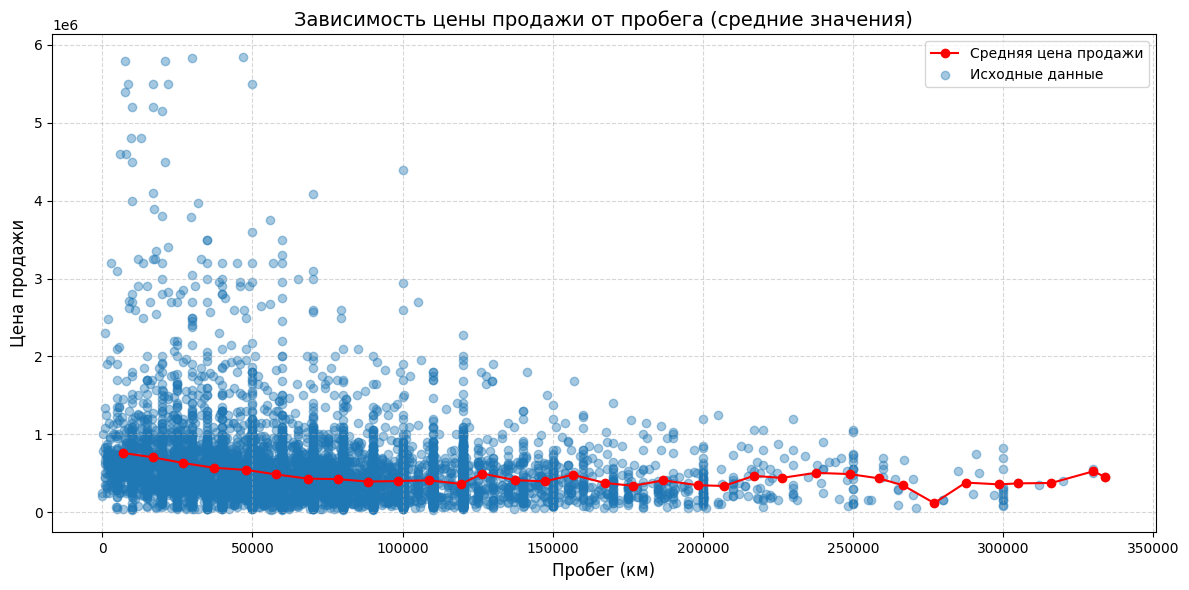

In [260]:
# Удаление двух машин с наивысшей ценой
combined_df = combined_df.sort_values(by='selling_price').iloc[:-2]
# Удаление 4 машин с наивысшим пробегом
combined_df = combined_df.sort_values(by='km_driven').iloc[:-4]
bin_size = 10000  # Размер одного интервала
combined_df_copy = combined_df.copy()
combined_df_copy['km_bins'] = pd.cut(combined_df_copy['km_driven'], bins=range(0, combined_df_copy['km_driven'].max() + bin_size, bin_size))

# Сгруппировать по интервалам (km_bins) и рассчитать среднее значение selling_price
grouped_df = combined_df_copy.groupby('km_bins', observed=False).agg(
    km_mean=('km_driven', 'mean'),  # Средний пробег в интервале (для X)
    selling_price_mean=('selling_price', 'mean')  # Средняя цена продажи (для Y)
).reset_index()

# Построение графика
plt.figure(figsize=(12, 6))

# Линия, соединяющая точки средней цены
plt.plot(grouped_df['km_mean'], grouped_df['selling_price_mean'], marker='o', color='red', label='Средняя цена продажи')
 
# График рассеяния для исходных данных
plt.scatter(combined_df_copy['km_driven'], combined_df_copy['selling_price'], alpha=0.4, label='Исходные данные')

# Настройка подписей
plt.xlabel('Пробег (км)', fontsize=12)
plt.ylabel('Цена продажи', fontsize=12)
plt.title('Зависимость цены продажи от пробега (средние значения)', fontsize=14)
plt.legend()

# Добавление сетки
plt.grid(True, linestyle='--', alpha=0.5)

# Отображение графика
plt.tight_layout()
plt.show()

### Вывод:


In [250]:
# Перевести fuel, seller_type, transmission
combined_df['brand'].unique()

array(['Mahindra', 'Maruti', 'Ford', 'Honda', 'Toyota', 'Hyundai',
       'Renault', 'Datsun', 'MG', 'Volkswagen', 'Volvo', 'Tata', 'Skoda',
       'Chevrolet', 'Kia', 'Jeep', 'Benz', 'BMW', 'Audi', 'Jaguar',
       'Nissan', 'Isuzu', 'Force', 'Lexus', 'Fiat', 'Land', 'Mitsubishi',
       'Daewoo', 'Ambassador', 'Opel', 'Ashok'], dtype=object)

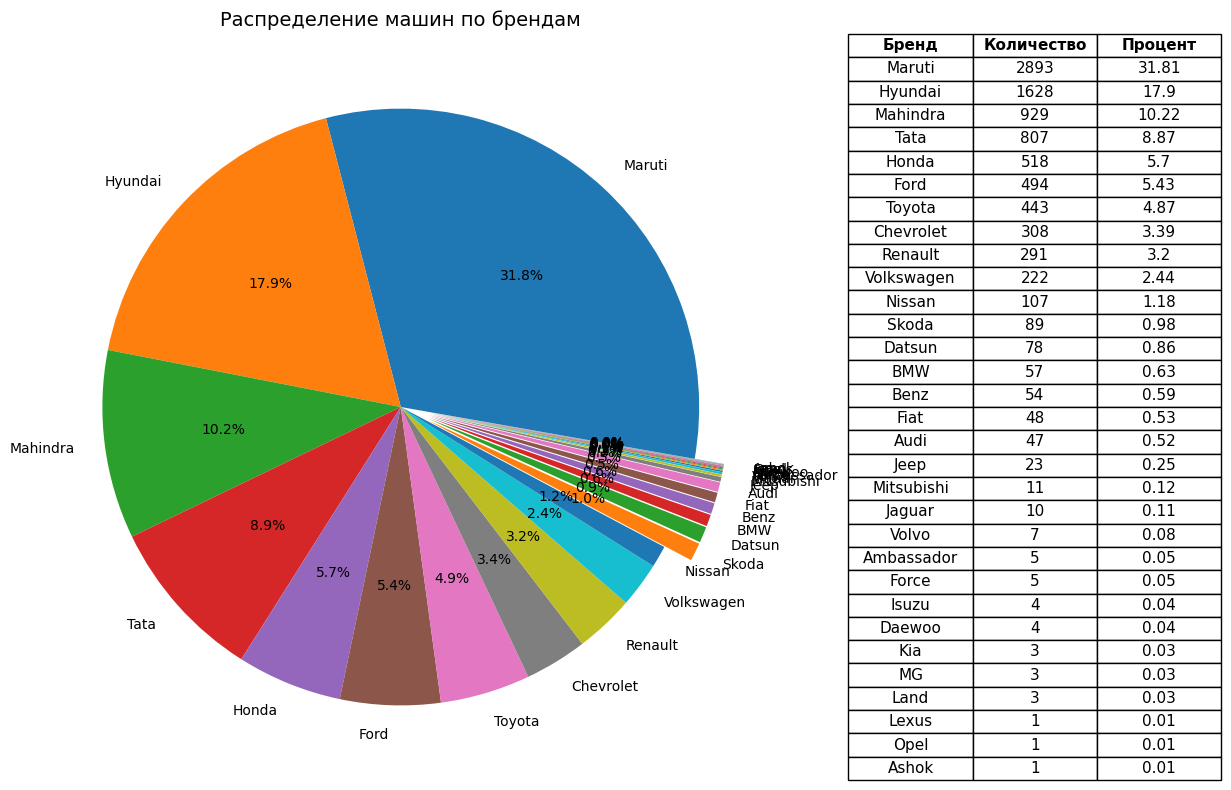

In [251]:
# Подсчет количества машин от каждого бренда
brand_counts = combined_df['brand'].value_counts()

# Вычисление процентов
brand_percent = (brand_counts / brand_counts.sum() * 100).round(2)

# Создание таблицы с брендами, количеством и процентами
table_data = pd.DataFrame({
    'Бренд': brand_counts.index,
    'Количество': brand_counts.values,
    'Процент': brand_percent.values
})

# Создание круговой диаграммы
plt.figure(figsize=(12, 8))  # Увеличим размеры, чтобы оставить место

explode = [0.1 if count < 100 else 0 for count in brand_counts]  # Смещаем сектора с малым количеством

plt.pie(brand_counts, labels=brand_counts.index, autopct='%1.1f%%', explode=explode, startangle=-10)

plt.title('Распределение машин по брендам', fontsize=14)

# Форматирование данных для таблицы
formatted_table_data = table_data.values.tolist()
formatted_table_data = [[str(cell) for cell in row] for row in formatted_table_data]

# Добавление таблицы справа от диаграммы
table = plt.table(cellText=formatted_table_data, 
                  colLabels=table_data.columns, 
                  loc='right', 
                  bbox=[1.1, 0, 0.5, 1], 
                  cellLoc='center', 
                  fontsize=12)

# Настройка стиля таблицы
for (i, j), cell in table.get_celld().items():
    if i == 0:  # Заголовок
        cell.set_text_props(weight='bold')
    cell.set_fontsize(12)
    cell.set_text_props(horizontalalignment='center', verticalalignment='center')  # Центровка текста

plt.tight_layout()
plt.show()


### Вывод:
График и таблица показывают, что рынок автомобилей значительно доминируется брендами Maruti (39.5%) и Hyundai (21.3%), которые вместе занимают более 60% от общего числа машин. Эти два бренда явно являются лидерами рынка. Далее, на третьем месте находится Tata с 8.7%, а следующие позиции занимают Honda (6.8%) и Ford (6.6%). Остальные бренды имеют заметно меньшие доли и практически незаметны на рынке. Таким образом, рынок явно сосредоточен вокруг нескольких крупных брендов, а доля остальных значительно фрагментирована.

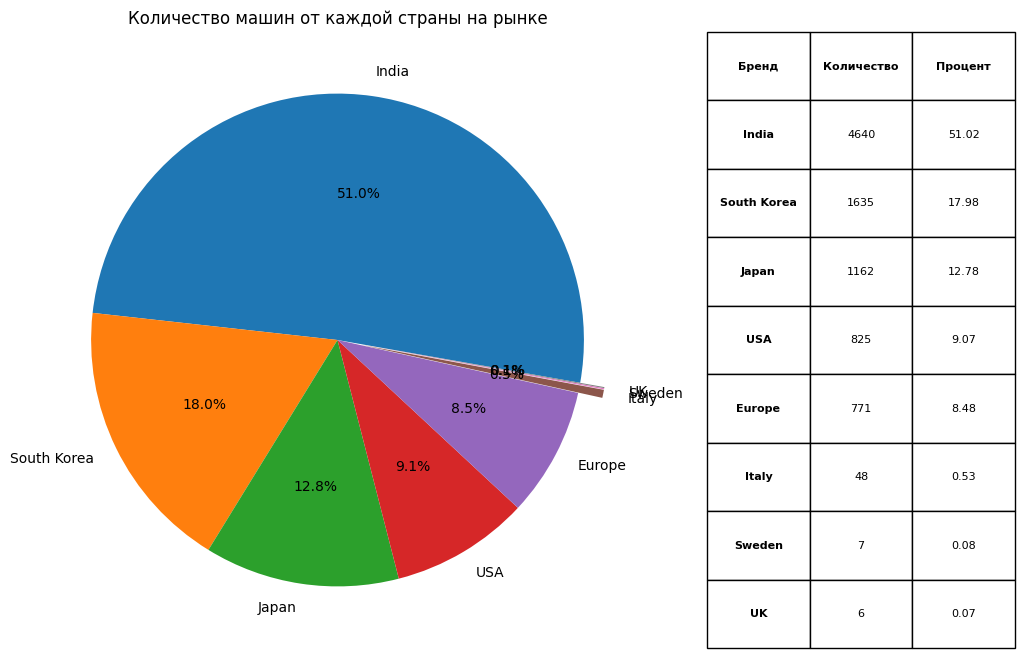

In [252]:
# Подсчет количества машин от каждой страны
country_counts = combined_df['country'].value_counts()

# Создание таблицы с данными страна-процент
table_data_country = country_counts.to_frame('Количество').reset_index()
table_data_country['Процент'] = (table_data_country['Количество'] / table_data_country['Количество'].sum()) * 100
table_data_country['Процент'] = table_data_country['Процент'].round(2)  # Округление процентов до второго знака

# Создание круговой диаграммы
plt.figure(figsize=(12, 8))  # Увеличьте размеры, чтобы дать больше места тексту

explode = [0.1 if count < 100 else 0 for count in country_counts]  # Смещаем сектора с малым количеством

plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', explode=explode, startangle=-10)

plt.title('Количество машин от каждой страны на рынке')

# Форматирование данных для центровки
formatted_table_data_country = table_data_country.values.tolist()
formatted_table_data_country = [[str(cell) for cell in row] for row in formatted_table_data_country]

# Добавление таблицы справа от диаграммы с выравниванием по центру
table = plt.table(cellText=formatted_table_data_country, 
                  colLabels=table_data.columns, 
                  loc='right', 
                  bbox=[1.1, 0, 0.5, 1], 
                  cellLoc='center', 
                  fontsize=12)

# Цикл для центровки текста в ячейках
for (i, j), cell in table.get_celld().items():
    if (i == 0) or (j == 0):  # Заголовки
        cell.set_text_props(weight='bold')
    cell.set_fontsize(12)  # Размер шрифта
    cell.set_text_props(horizontalalignment='center', verticalalignment='center')  # Центровка текста

plt.show()

### Вывод:
График и таблица показывают, что почти половина автомобилей на рынке (49.1%) произведена в Индии, что делает эту страну крупнейшим поставщиком. Италия представлена минимальным количеством автомобилей, составляя лишь 0.7% от их общего числа. Таким образом, рынок автомобилей характеризуется сильным доминированием индийских производителей, к которым в совокупности добавляются страны Азии, обеспечивающие почти три четверти предложения.

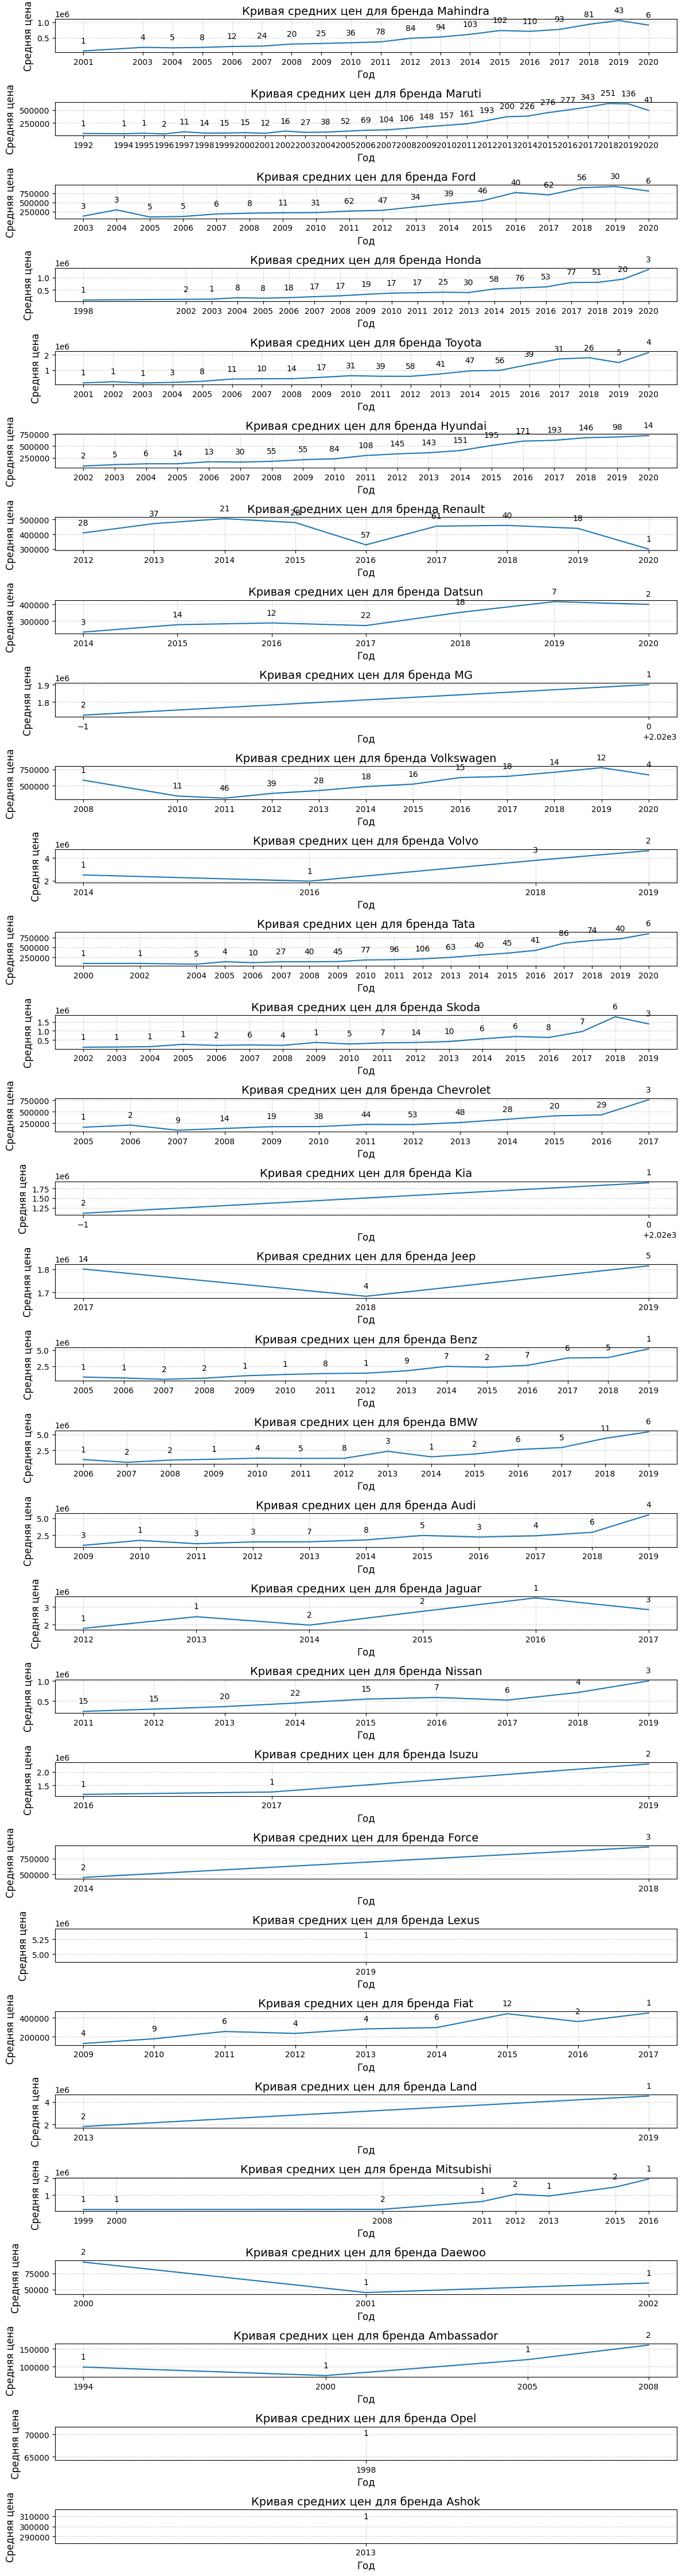

In [253]:
# Список брендов
brands = combined_df['brand'].unique()

# Количество брендов
n_brands = len(brands)

plt.figure(figsize=(12, 45))

# Для каждого бренда
for i, brand in enumerate(brands):
    brand_data = combined_df[combined_df['brand'] == brand]

    # Группировка данных по году и расчет средней цены
    year_mean_price = brand_data.groupby('year')['selling_price'].mean().reset_index()
    year_count = brand_data.groupby('year')['selling_price'].count().reset_index()

    # Создание субплота
    plt.subplot(n_brands, 1, i + 1)

    # Построение графика
    plt.plot(
        year_mean_price['year'],  # Годы
        year_mean_price['selling_price'],  # Средние цены
    )

    # Добавление меток количества автомобилей
    for j, row in year_mean_price.iterrows():
        count = year_count.loc[year_count['year'] == row['year'], 'selling_price'].values[0]
        plt.annotate(f'{count}', (row['year'], row['selling_price']), textcoords="offset points", xytext=(0, 10), ha='center')

    # Настройка графика
    plt.title(f'Кривая средних цен для бренда {brand}', fontsize=14)
    plt.xlabel('Год', fontsize=12)
    plt.ylabel('Средняя цена', fontsize=12)

    plt.xticks(year_mean_price['year'])  # Задание меток на оси X
    plt.grid(True, linestyle='--', alpha=0.5)

# Сжатие макета
plt.tight_layout()
plt.show()

In [254]:
combined_df[combined_df['brand'] == 'MG']

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,brand,model,Nm,rpm,price_category,country,years_old,km_per_year,km_per_owner,fuel_consumption
1684,2020,1900000,1600,Petrol,Dealer,Automatic,1,13.96,1451.0,141.0,...,MG,Hector Sharp DCT Dualtone,250.0,1600.0,Premium,UK,5,319.999936,1599.9984,103.939821
3516,2019,1700000,16500,Petrol,Dealer,Automatic,1,13.96,1451.0,141.0,...,MG,Hector Smart DCT,250.0,1600.0,Premium,UK,6,2749.999542,16499.9835,103.939821
132,2019,1750000,19000,Petrol,Dealer,Automatic,1,13.96,1451.0,141.0,...,MG,Hector Sharp AT BSIV,250.0,1600.0,Premium,UK,6,3166.666139,18999.9810,103.939821


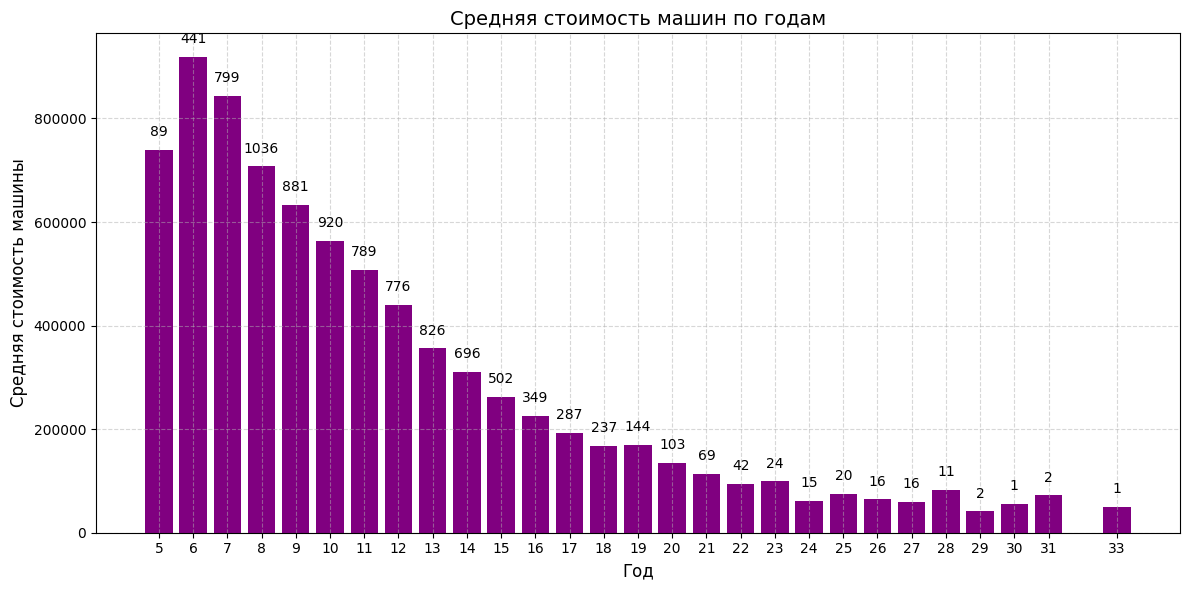

In [255]:
# Группировка данных по году и расчет средней цены
years_old_mean_price = combined_df.groupby('years_old')['selling_price'].mean().reset_index()
years_old_count = combined_df.groupby('years_old')['selling_price'].count().reset_index()

# Создание столбчатой диаграммы
plt.figure(figsize=(12, 6))
plt.bar(years_old_mean_price['years_old'], years_old_mean_price['selling_price'], color='Purple')

# Добавление количества машин над каждым столбцом
for i, row in years_old_mean_price.iterrows():
    count = years_old_count.loc[years_old_count['years_old'] == row['years_old'], 'selling_price'].values[0]
    plt.annotate(f'{count}', (row['years_old'], row['selling_price']), textcoords="offset points", xytext=(0, 10), ha='center')

# Настройка графика
plt.xlabel('Год', fontsize=12)
plt.ylabel('Средняя стоимость машины', fontsize=12)
plt.title('Средняя стоимость машин по годам', fontsize=14)
plt.xticks(years_old_mean_price['years_old'])  # Задание меток на оси X
plt.grid(True, linestyle='--', alpha=0.5)

# Сжатие макета
plt.tight_layout()
plt.show()

### Вывод
Наибольшая средняя цена наблюдается в более ранние годы (с 5 по 8), после чего происходит постепенное снижение к более поздним годам (с 15 по 23). Это вполне ожидаемо и объясняется естественной амортизацией автомобилей: более новые машины дороже, старые — дешевле. 

In [256]:
print(combined_df.isnull().sum())

year                0
selling_price       0
km_driven           0
fuel                0
seller_type         0
transmission        0
owner               0
mileage             0
engine              0
max_power           0
seats               0
brand               0
model               0
Nm                  0
rpm                 0
price_category      0
country             0
years_old           0
km_per_year         0
km_per_owner        0
fuel_consumption    0
dtype: int64


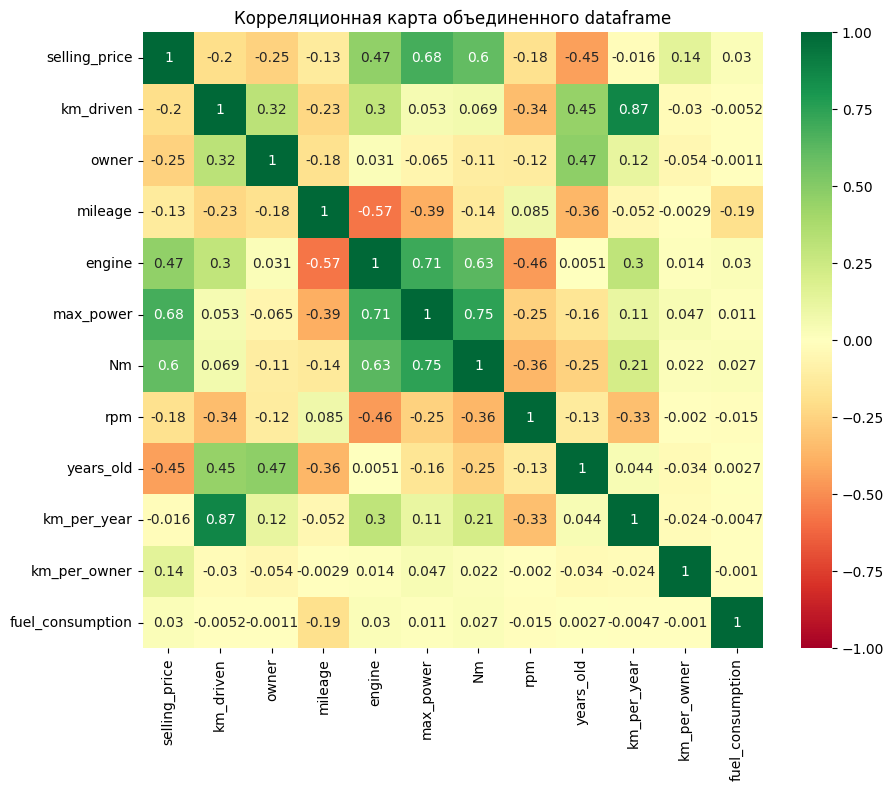

In [257]:
# Удаляем категориальные столбцы
hm = combined_df.drop(['fuel', 'seller_type', 'model', 'brand', 'transmission', 'country', 'seats', 'price_category', 'year'], axis=1) # seats?

# Создаем корреляционную матрицу
corr_matrix = hm.corr()

# Строим тепловую карту
plt.figure(figsize=(10, 8))  # размер графика
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title("Корреляционная карта объединенного dataframe")
plt.show()